In [1]:
#Rutas
import os
import sys

sys.path.append(os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
from src.modelo import p_theta, riesgo_logistico
from src.optimizacion import ajustar_modelo
from src.simulacion import generar_datos

os.makedirs('../resultados', exist_ok=True)


Ejercicio 1: Superficie del riesgo logístico

Theta estimado: [0.65000893 2.5844874 ]
Riesgo Mínimo: 0.278454


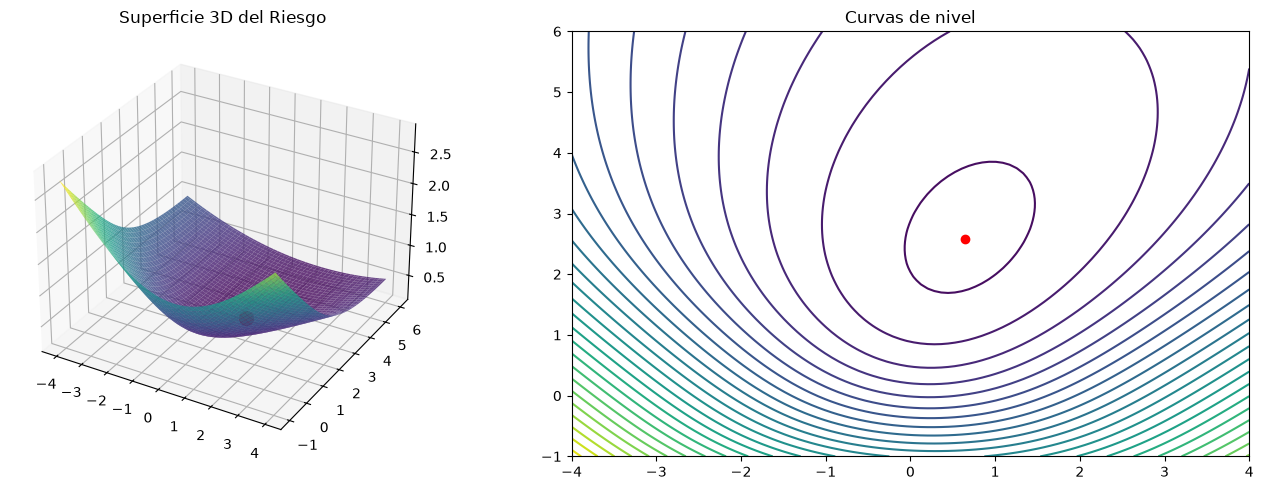

R(th_hat) < R(th_hat + (0.1, 0)): True
R(th_hat) < R(th_hat + (0, 0.1)): True


In [2]:
x_ej1 = np.array([-2, -1.5, -1, -0.5, 0, 0.5, 1, 1.5, 2])
y_ej1 = np.array([0, 0, 0, 1, 0, 1, 1, 1, 1])

th0_vals = np.linspace(-4, 4, 100)
th1_vals = np.linspace(-1, 6, 100)
T0, T1 = np.meshgrid(th0_vals, th1_vals)
R_vals = np.zeros_like(T0)

for i in range(T0.shape[0]):
    for j in range(T0.shape[1]):
        R_vals[i,j] = riesgo_logistico([T0[i,j], T1[i,j]], x_ej1, y_ej1)

theta_hat, min_risk, _ = ajustar_modelo(x_ej1, y_ej1, theta_init=(0.0, 0.0))
print(f"Theta estimado: {theta_hat}")
print(f"Riesgo Mínimo: {min_risk:.6f}")

fig = plt.figure(figsize=(14, 5))
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(T0, T1, R_vals, cmap='viridis', alpha=0.8)
ax1.scatter(theta_hat[0], theta_hat[1], min_risk, color='red', s=100, label='Minimizador')
ax1.set_title('Superficie 3D del Riesgo')

ax2 = fig.add_subplot(122)
cp = ax2.contour(T0, T1, R_vals, levels=30, cmap='viridis')
ax2.plot(theta_hat[0], theta_hat[1], 'ro', label='Minimizador')
ax2.set_title('Curvas de nivel')

plt.tight_layout()
plt.savefig('../resultados/ejercicio1.png', bbox_inches='tight')
plt.show()

r_opt = riesgo_logistico(theta_hat, x_ej1, y_ej1)
r_up0 = riesgo_logistico(theta_hat + np.array([0.1, 0.0]), x_ej1, y_ej1)
r_up1 = riesgo_logistico(theta_hat + np.array([0.0, 0.1]), x_ej1, y_ej1)
print(f"R(th_hat) < R(th_hat + (0.1, 0)): {r_opt < r_up0}")
print(f"R(th_hat) < R(th_hat + (0, 0.1)): {r_opt < r_up1}")


Ejercicio 2: Datos separables y no separables

Conjunto | ||th_hat||_2 | Riesgo
A (Sep)  | 43.0476      | 0.000010
B (NoSep)| 2.6650      | 0.278454


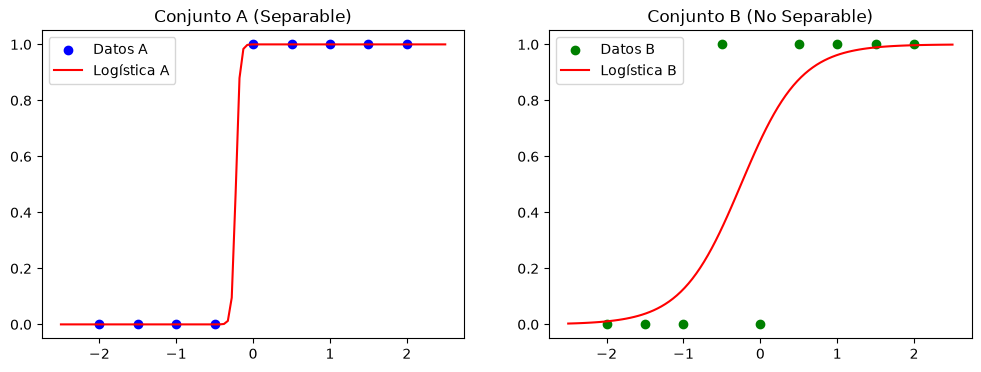


Maxiter 10  -> Norma: 16.0270, Riesgo: 0.005126
Maxiter 100 -> Norma: 43.0476, Riesgo: 0.000010
La afirmación correcta es la II: La norma aumenta mientras el riesgo disminuye hacia cero.


In [3]:
yA = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1])
yB = np.array([0, 0, 0, 1, 0, 1, 1, 1, 1])

th_A, r_A, _ = ajustar_modelo(x_ej1, yA)
th_B, r_B, _ = ajustar_modelo(x_ej1, yB)

print("Conjunto | ||th_hat||_2 | Riesgo")
print(f"A (Sep)  | {np.linalg.norm(th_A):.4f}      | {r_A:.6f}")
print(f"B (NoSep)| {np.linalg.norm(th_B):.4f}      | {r_B:.6f}")

x_lin = np.linspace(-2.5, 2.5, 100)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.scatter(x_ej1, yA, c='blue', label='Datos A')
ax1.plot(x_lin, p_theta(x_lin, th_A), 'r-', label='Logística A')
ax1.set_title('Conjunto A (Separable)'); ax1.legend()

ax2.scatter(x_ej1, yB, c='green', label='Datos B')
ax2.plot(x_lin, p_theta(x_lin, th_B), 'r-', label='Logística B')
ax2.set_title('Conjunto B (No Separable)'); ax2.legend()
plt.savefig('../resultados/ejercicio2.png', bbox_inches='tight')
plt.show()

th_A10, r_A10, _ = ajustar_modelo(x_ej1, yA, maxiter=10)
th_A100, r_A100, _ = ajustar_modelo(x_ej1, yA, maxiter=100)
print(f"\nMaxiter 10  -> Norma: {np.linalg.norm(th_A10):.4f}, Riesgo: {r_A10:.6f}")
print(f"Maxiter 100 -> Norma: {np.linalg.norm(th_A100):.4f}, Riesgo: {r_A100:.6f}")
print("La afirmación correcta es la II: La norma aumenta mientras el riesgo disminuye hacia cero.")


Ejercicio 3: Recuperación de parámetros

In [4]:
ns = [50, 200, 1000]
th_star = np.array([-1.0, 2.0])
errores = {}

print("n    | theta_0 | theta_1 | e_n")
print("-" * 32)
for n in ns:
    X_n, Y_n = generar_datos(n, th_star, seed=2026)
    th_hat_n, min_r, _ = ajustar_modelo(X_n, Y_n)
    e_n = np.linalg.norm(th_hat_n - th_star)
    errores[n] = e_n
    print(f"{n:<4} | {th_hat_n[0]:>7.4f} | {th_hat_n[1]:>7.4f} | {e_n:.4f}")

min_n = min(errores, key=errores.get)
print(f"\nMenor error obtenido con n = {min_n}")
print(f"¿e_1000 < e_50?: {errores[1000] < errores[50]}")

n    | theta_0 | theta_1 | e_n
--------------------------------
50   | -1.6138 |  2.6844 | 0.9193
200  | -0.8178 |  1.8464 | 0.2383
1000 | -0.9649 |  1.8706 | 0.1340

Menor error obtenido con n = 1000
¿e_1000 < e_50?: True


Ejercicio 4: Interpretación de los parámetros

th0=-2, th1=1 -> x* = 2.0, p(x*) = 0.5
th0=0, th1=1 -> x* = 0.0, p(x*) = 0.5
th0=2, th1=1 -> x* = -2.0, p(x*) = 0.5
------------------------------
th0=0, th1=1 -> p(1) - p(-1) = 0.4621
th0=0, th1=2 -> p(1) - p(-1) = 0.7616
th0=0, th1=5 -> p(1) - p(-1) = 0.9866


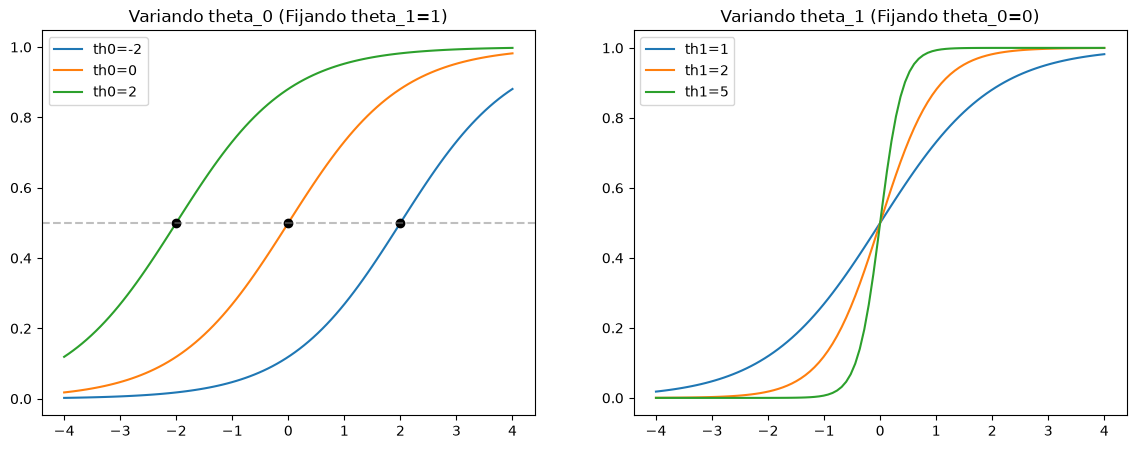

El modelo con theta_1 = 5 presenta la transición más abrupta.


In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
x_lin = np.linspace(-4, 4, 100)

t1 = 1
for t0 in [-2, 0, 2]:
    p_vals = p_theta(x_lin, [t0, t1])
    ax1.plot(x_lin, p_vals, label=f'th0={t0}')
    x_star = -t0 / t1
    ax1.plot(x_star, 0.5, 'ko')
    print(f"th0={t0}, th1={t1} -> x* = {x_star}, p(x*) = {p_theta(x_star, [t0, t1])}")
ax1.axhline(0.5, ls='--', c='gray', alpha=0.5)
ax1.set_title('Variando theta_0 (Fijando theta_1=1)')
ax1.legend()

print("-" * 30)
t0 = 0
for t1 in [1, 2, 5]:
    p_vals = p_theta(x_lin, [t0, t1])
    ax2.plot(x_lin, p_vals, label=f'th1={t1}')
    diff = p_theta(1, [t0, t1]) - p_theta(-1, [t0, t1])
    print(f"th0={t0}, th1={t1} -> p(1) - p(-1) = {diff:.4f}")
ax2.set_title('Variando theta_1 (Fijando theta_0=0)')
ax2.legend()

plt.savefig('../resultados/ejercicio4.png', bbox_inches='tight')
plt.show()
print("El modelo con theta_1 = 5 presenta la transición más abrupta.")



Ejercicio 5: Verosimilitud y estabilidad numérica

In [6]:
X_5k, Y_5k = generar_datos(5000, th_star, seed=2026)
p_5k = p_theta(X_5k, th_star)

terms = np.where(Y_5k == 1, p_5k, 1 - p_5k)
L_theta = np.prod(terms)

log_terms = np.where(Y_5k == 1, np.log(p_5k), np.log(1 - p_5k))
log_L_theta = np.sum(log_terms)

print(f"L(theta*) directa: {L_theta}")
print(f"log L(theta*): {log_L_theta}")
print("\nLa log-verosimilitud es un número finito negativo, mientras que L(theta) da 0.0 por underflow.")

n = 5000
R_emp = riesgo_logistico(th_star, X_5k, Y_5k)
Delta = np.abs(-log_L_theta - (n * R_emp))

print(f"\nR_S(theta*): {R_emp:.6f}")
print(f"Delta = |-log L - n*R_S| = {Delta}")
print(f"¿Delta < 1e-8?: {Delta < 1e-8}")

L(theta*) directa: 0.0
log L(theta*): -1954.920071716625

La log-verosimilitud es un número finito negativo, mientras que L(theta) da 0.0 por underflow.

R_S(theta*): 0.390984
Delta = |-log L - n*R_S| = 2.2737367544323206e-13
¿Delta < 1e-8?: True
